In [1]:
import warnings

warnings.filterwarnings("ignore")

#### **API 키 설정**

In [2]:
# API KEY를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API KEY 정보로드
load_dotenv()

True

#### **State 설정**

In [3]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import SystemMessage, HumanMessage


class State(TypedDict):
    messages: Annotated[list, add_messages]

#### **도구 설정(웹 검색, PythonREPL)**

In [4]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_experimental.utilities import PythonREPL
from langchain_core.tools import tool

web_search = TavilySearchResults(max_results=2)
repl = PythonREPL()


@tool
def python_repl(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. chart labels should be written in English.
    This is visible to the user."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    result_str = f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )


tools = [web_search, python_repl]
tool_node = ToolNode(tools)

C:\Users\park0\AppData\Local\Temp\ipykernel_42168\3710682684.py:6: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  web_search = TavilySearchResults(max_results=2)


#### **에이전트에게 도구 인지시키기**

In [5]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)


def agent(state: State):
    result = llm_with_tools.invoke(state["messages"])
    return {"messages": [result]}

In [6]:
def should_continue(state):
    messages = state["messages"]
    last_message = messages[-1]
    if not last_message.tool_calls:
        return "end"
    else:
        return "continue"

In [7]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import tools_condition
from langgraph.graph import StateGraph
from langgraph.checkpoint.memory import MemorySaver

workflow = StateGraph(State)

workflow.add_node("agent", agent)
workflow.add_node("tool", tool_node)

workflow.add_edge(START, "agent")

# We now add a conditional edge
workflow.add_conditional_edges(
    "agent",
    should_continue,
    {
        "continue": "tool",
        # Otherwise we finish.
        "end": END,
    },
)

# We now add a normal edge from `tools` to `agent`.
# This means that after `tools` is called, `agent` node is called next.
workflow.add_edge("tool", "agent")

# Set up memory
memory = MemorySaver()

graph = workflow.compile(checkpointer=memory, interrupt_before=["tool"])

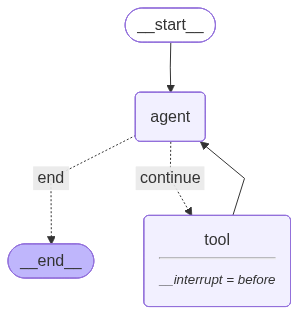

In [8]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
initial_input = {
    "messages": [HumanMessage(content="미국의 최근 5개년(~2023) GDP 차트를 그려줄래?")]
}
thread = {"configurable": {"thread_id": "13"}}
async for chunk in graph.astream(initial_input, thread, stream_mode="updates"):
    for node, values in chunk.items():
        print(f"Receiving update from node: '{node}'")
        print(values)
        print("\n\n")

Receiving update from node: 'agent'
{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_SejyyeSk9mcsIQ9T3WPUduDX', 'function': {'arguments': '{"query":"USA GDP data 2019 to 2023"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 168, 'total_tokens': 195, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'id': 'chatcmpl-CGkt1ejb3rYcBnWQopWzW6830cckL', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--9374a631-46f0-4629-80e5-738349eaa6e0-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'USA GDP data 2019 to 2023'}, 'id': 'call_SejyyeSk9mcsIQ9T3WPUduDX', 'type':

In [10]:
async for chunk in graph.astream(None, thread, stream_mode="updates"):
    for node, values in chunk.items():
        print(f"Receiving update from node: '{node}'")
        print(values)
        print("\n\n")

Receiving update from node: 'tool'
{'messages': [ToolMessage(content='[{"title": "U.S. GDP | Historical Chart & Data - Macrotrends", "url": "https://www.macrotrends.net/global-metrics/countries/usa/united-states/gdp-gross-domestic-product", "content": "## U.S. GDP\\n\\nPopulation\\nEconomy\\nTrade\\nHealth\\nEducation\\nDevelopment\\nLabor Force\\nEnvironment\\nCrime\\nImmigration\\nOther\\n\\nGDP\\nGDP Growth Rate\\nGDP Per Capita\\nDebt to GDP\\nInflation Rate\\nManufacturing\\nGNI\\nGNI Per Capita\\nGNP\\n\\n##### U.S. GDP for 2023 was 27.721 trillion US dollars, a 6.59% increase from 2022. [...] U.S. GDP for 2022 was 26.007 trillion US dollars, a 9.82% increase from 2021.\\n U.S. GDP for 2021 was 23.681 trillion US dollars, a 10.9% increase from 2020.\\n U.S. GDP for 2020 was 21.354 trillion US dollars, a 0.86% decline from 2019. [...] | United States GDP  GDP (US $) | |\\n --- |\\n| 2023 | $27.721T |\\n| 2022 | $26.007T |\\n| 2021 | $23.681T |\\n| 2020 | $21.354T |\\n| 2019 | $21.

Python REPL can execute arbitrary code. Use with caution.


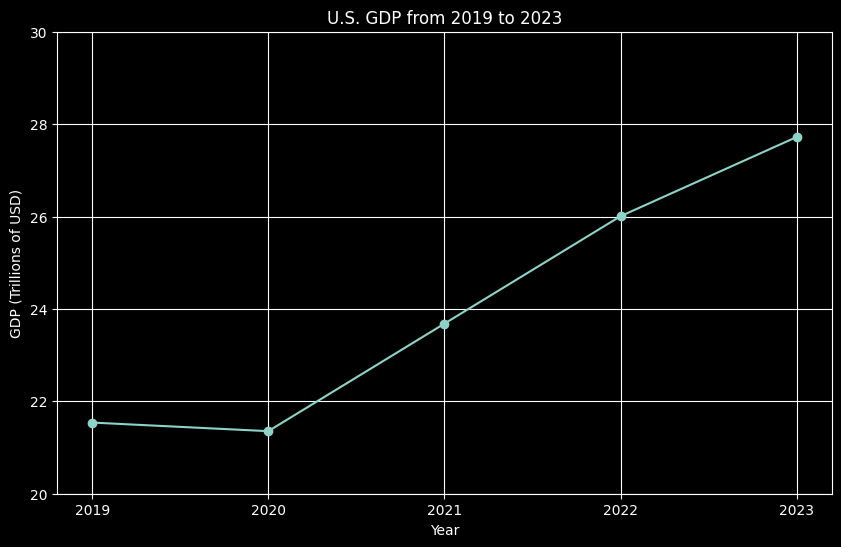

Receiving update from node: 'tool'
{'messages': [ToolMessage(content="Successfully executed:\n```python\nimport matplotlib.pyplot as plt\nimport numpy as np\n\n# Data for the United States GDP from 2019 to 2023\nyears = np.array([2019, 2020, 2021, 2022, 2023])\nGDP_values = np.array([21.540, 21.354, 23.681, 26.007, 27.721])  # in trillion USD\n\nplt.figure(figsize=(10, 6))\nplt.plot(years, GDP_values, marker='o')\nplt.title('U.S. GDP from 2019 to 2023')\nplt.xlabel('Year')\nplt.ylabel('GDP (Trillions of USD)')\nplt.xticks(years)\nplt.grid(True)\nplt.ylim(20, 30)\nplt.show()\n```\nStdout: \n\nIf you have completed all tasks, respond with FINAL ANSWER.", name='python_repl', id='65ddcb02-ae88-42fa-a388-d7b93e65aea1', tool_call_id='call_UJCVzVMKUbL6UzJw1mOiPo6v')]}



Receiving update from node: 'agent'
{'messages': [AIMessage(content='Here is the chart depicting the U.S. GDP from 2019 to 2023:\n\n- **2019**: $21.540 trillion\n- **2020**: $21.354 trillion\n- **2021**: $23.681 trillion\n- *

In [11]:
async for chunk in graph.astream(None, thread, stream_mode="updates"):
    for node, values in chunk.items():
        print(f"Receiving update from node: '{node}'")
        print(values)
        print("\n\n")

In [12]:
async for chunk in graph.astream(None, thread, stream_mode="updates"):
    for node, values in chunk.items():
        print(f"Receiving update from node: '{node}'")
        print(values)
        print("\n\n")

In [13]:
async for chunk in graph.astream(None, thread, stream_mode="updates"):
    for node, values in chunk.items():
        print(f"Receiving update from node: '{node}'")
        print(values)
        print("\n\n")